In [2]:
#====================================================================
#==     MACHINE LEARNING COURSEWORK - 2    STUDENT ID - A00096829  ==
#====================================================================

In [3]:
# IMPORT THE REQURIED LIBRARIES
#===============================

# TensorFlow (main deep learning)
import tensorflow as tf
# TensorFlow Datasets (used to load STL-10 )
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models

import matplotlib.pyplot as plt  
import numpy as np
import random
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier

In [4]:
# Print TensorFlow version to verify.
#------------------------------------
print("TensorFlow version:", tf.__version__)

# Load STL-10 dataset
# split both training and testing sets
# supervised=True --> image and label pairs
# with_info=True --> (number of samples, class names)

(train_ds, test_ds), ds_info = tfds.load(
    'stl10',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

# Print dataset to verify correct loading
print("Dataset loaded successfully")
print("Number of training samples:", ds_info.splits['train'].num_examples)
print("Number of testing samples:", ds_info.splits['test'].num_examples)

# Print class all names
print("Class names:", ds_info.features['label'].names)

TensorFlow version: 2.20.0
Dataset loaded successfully
Number of training samples: 5000
Number of testing samples: 8000
Class names: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [5]:
# Take one example from training dataset
#----------------------------------------
for image, label in train_ds.take(1):
    
    # Define and print input variable X
    print("Image shape:", image.shape)
    
    # Define and print output variable y
    print("Label value:", label.numpy())

Image shape: (96, 96, 3)
Label value: 1


In [6]:
# Image resize (reduce from 96x96 to 64x64)
#---------------------------------------------------
IMG_SIZE = 64

# Define preprocessing function
def preprocess(image, label):
    
    # Resize image to 64x64
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    
    # Normalize pixel values from [0,255] to [0,1]
    image = image / 255.0
    
    return image, label

# Apply preprocessing to training and test datasets
train_ds = train_ds.map(preprocess)
test_ds = test_ds.map(preprocess)

print("Preprocessing applied successfully!")

Preprocessing applied successfully!


In [7]:
# Check one processed sample
#---------------------------
for image, label in train_ds.take(1):
    
    print("New image shape:", image.shape)  # Should now be (64, 64, 3)
    
    print("Minimum pixel value:", tf.reduce_min(image).numpy())  # Should be 0.0
    print("Maximum pixel value:", tf.reduce_max(image).numpy())  # Should be 1.0

New image shape: (64, 64, 3)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [8]:
# Get the dataset information
#----------------------------
# Get total number of training samples
TOTAL_TRAIN = ds_info.splits['train'].num_examples

# Calculate 80% of data for training
TRAIN_SIZE = int(0.8 * TOTAL_TRAIN)

# Reload full training set (important for proper splitting)
full_train = tfds.load('stl10', split='train', as_supervised=True)
full_train = full_train.map(preprocess)

# Take first 80% as training set
train_ds = full_train.take(TRAIN_SIZE)

# Skip first 80% and use remaining 20% as validation set
val_ds = full_train.skip(TRAIN_SIZE)

print("Training samples:", TRAIN_SIZE)
print("Validation samples:", TOTAL_TRAIN - TRAIN_SIZE)

Training samples: 4000
Validation samples: 1000


In [9]:
# Define batch size
#------------------
BATCH_SIZE = 32

# Batch datasets
train_ds = train_ds.batch(BATCH_SIZE)
val_ds = val_ds.batch(BATCH_SIZE)
test_ds = test_ds.batch(BATCH_SIZE)

print("Batching complete!")

# Check one batch
for images, labels in train_ds.take(1):
    
    print("Batch image shape:", images.shape)  # Expected: (32, 64, 64, 3)
    print("Batch label shape:", labels.shape)  # Expected: (32,)

Batching complete!
Batch image shape: (32, 64, 64, 3)
Batch label shape: (32,)


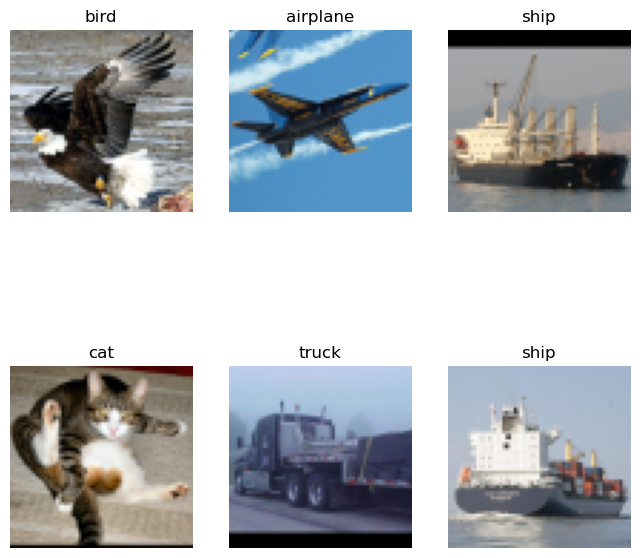

In [10]:
# Get class names
#----------------
class_names = ds_info.features['label'].names

# Display 6 sample images
for images, labels in train_ds.take(1):
    
    plt.figure(figsize=(8,8))
    
    for i in range(6):
        plt.subplot(2,3,i+1)
        plt.imshow(images[i])
        plt.title(class_names[labels[i]])
        plt.axis("off")
    
    plt.show()

In [11]:
# Build the CNN Model
#====================


# Create Sequential model
model = models.Sequential()


# Input Layer
# ------------
# Input shape (64, 64, 3)
model.add(layers.Input(shape=(64, 64, 3)))


# Hidden Layer Block 1
# ---------------------
model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))


# Hidden Layer Block 2
# ---------------------
model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))


# Hidden Layer Block 3
# --------------------
model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))


# Flatten before Dense layers
# -------------------------
model.add(layers.Flatten())

# Fully Connected Layer
model.add(layers.Dense(128, activation='relu'))

# Dropout to reduce overfitting
model.add(layers.Dropout(0.5))


# Output Layer
# -------------
model.add(layers.Dense(10, activation='softmax'))

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64, 64, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       1,048,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,144,138 (4.36 MB)

 Trainable params: 1,143,690 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [13]:
# compilation test of CNN model
#------------------------------
model.compile(
    optimizer='adam',                       
    loss='sparse_categorical_crossentropy',  
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [14]:
# Train the model
#----------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 144ms/step - accuracy: 0.2342 - loss: 2.4509 - val_accuracy: 0.1470 - val_loss: 4.9598
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/step - accuracy: 0.2720 - loss: 1.9073 - val_accuracy: 0.1730 - val_loss: 2.5093
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 130ms/step - accuracy: 0.3215 - loss: 1.7562 - val_accuracy: 0.2540 - val_loss: 1.9866
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 128ms/step - accuracy: 0.3532 - loss: 1.6665 - val_accuracy: 0.4050 - val_loss: 1.6949
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 129ms/step - accuracy: 0.3855 - loss: 1.5847 - val_accuracy: 0.3620 - val_loss: 1.8978
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 134ms/step - accuracy: 0.3947 - loss: 1.5394 - val_accuracy: 0.4500 - val_loss: 1.4961
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 129ms/step - accuracy: 0.4110 - loss: 1.4824 - val_accuracy: 0.4080 - val_loss: 1.7493
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 128ms/step - accuracy: 0.4412 - loss: 1

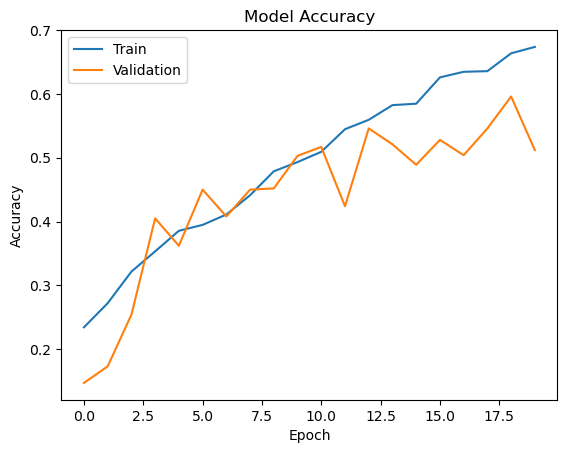

In [15]:
# Plot Accuracy
#--------------

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

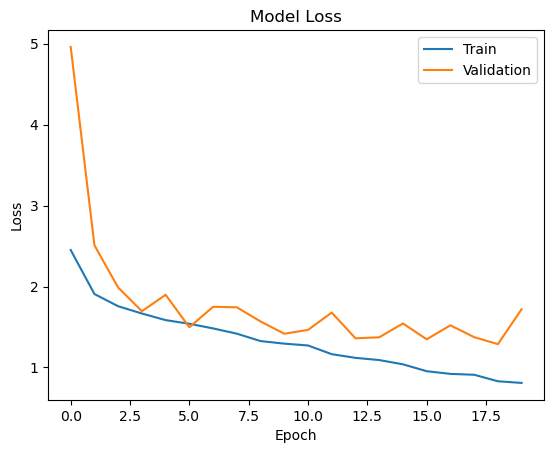

In [16]:
# Plot Loss
#-----------
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [17]:
#Evaluate the Test results of given Dataset
#------------------------------------------
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.5082 - loss: 1.7467
Test Accuracy: 0.5082499980926514
Test Loss: 1.7466503381729126


In [18]:
# Confusion Matrix
#------------------
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Get predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

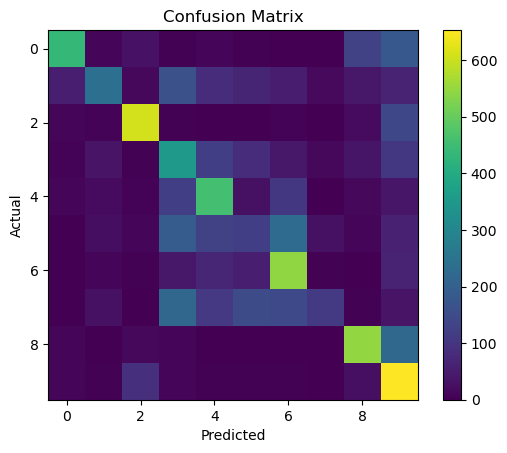

In [19]:
# Plot Confusion Matrix
#----------------------
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [20]:
# Classification Report (Precision, Recall, F1)
#----------------------------------------------

print(classification_report(y_true, y_pred))

# Precision          - Correct positive predictions
# Recall             - Ability to detect all class instances
# F1-score           - Balance between precision & recall
# Confusion Matrix	 - Class-level performance

              precision    recall  f1-score   support

           0       0.81      0.54      0.65       800
           1       0.63      0.30      0.40       800
           2       0.78      0.76      0.77       800
           3       0.32      0.44      0.37       800
           4       0.46      0.57      0.51       800
           5       0.24      0.15      0.19       800
           6       0.48      0.68      0.56       800
           7       0.62      0.14      0.23       800
           8       0.66      0.68      0.67       800
           9       0.42      0.82      0.55       800

    accuracy                           0.51      8000
   macro avg       0.54      0.51      0.49      8000
weighted avg       0.54      0.51      0.49      8000



In [21]:
# DECISION TREE MODEL (LO3 Requirement)
# Using same train_ds and test_ds
# ======================================

# Convert TensorFlow dataset to NumPy arrays
X_train_dt = []
y_train_dt = []

for images, labels in train_ds.unbatch():
    X_train_dt.append(tf.reshape(images, [-1]).numpy())
    y_train_dt.append(labels.numpy())

X_test_dt = []
y_test_dt = []

for images, labels in test_ds.unbatch():
    X_test_dt.append(tf.reshape(images, [-1]).numpy())
    y_test_dt.append(labels.numpy())

X_train_dt = np.array(X_train_dt)
y_train_dt = np.array(y_train_dt)
X_test_dt = np.array(X_test_dt)
y_test_dt = np.array(y_test_dt)

print("Decision Tree data prepared!")

Decision Tree data prepared!


In [22]:
# Train Decision Tree
#---------------------
dt_model = DecisionTreeClassifier(max_depth=20, random_state=42)

dt_model.fit(X_train_dt, y_train_dt)

# Predict
dt_predictions = dt_model.predict(X_test_dt)

# Accuracy
dt_accuracy = accuracy_score(y_test_dt, dt_predictions)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.258875


In [29]:
# FINAL MODEL COMPARISON
# =======================

print("\n================ FINAL MODEL COMPARISON ================\n")

print("┌──────┬───────────────────────────────┬───────────────┐")
print("│ S.No │ Model                         │ Accuracy (%)  │")
print("├──────┼───────────────────────────────┼───────────────┤")
print(f"│ {1:<4} │ {'CNN':<29} │ {test_accuracy*100:>13.5f} │")
print(f"│ {2:<4} │ {'Decision Tree':<29} │ {dt_accuracy*100:>13.5f} │")
print("└──────┴───────────────────────────────┴───────────────┘")


================ FINAL MODEL COMPARISON ================

┌──────┬───────────────────────────────┬───────────────┐
│ S.No │ Model                         │ Accuracy (%)  │
├──────┼───────────────────────────────┼───────────────┤
│ 1    │ CNN                           │      50.82500 │
│ 2    │ Decision Tree                 │      25.88750 │
└──────┴───────────────────────────────┴───────────────┘
